# Efficient Array Computing

This episode describes xxxxx

#### Contents of this notebook

- [2.1 Why Can Python Be Slow?](#2.1-Why-Can-Python-Be-Slow?)
    - [2.1.1 Dynamic typing](#2.1.1-Dynamic-typing)
    - [2.1.2 Flexible data structures](#2.1.2-Flexible-data-structures)
- [2.2 Numpy](#2.2-Numpy)
    - [2.2.1 Arrays](#2.2.1-Arrays)
    - [2.2.2 Data types](#2.2.2-Data-types)
    - [2.2.3 Creating NumPy arrays](#2.2.3-Creating-NumPy-arrays)
    - [2.2.4 Array operations and manipulations](#2.2.4-Array-operations-and-manipulations)
    - [2.2.5 Array indexing](#2.2.5-Array-indexing)
    - [2.2.6 Array reshaping](#2.2.6-Array-reshaping)
    - [2.2.7 I/O with NumPy](#2.2.7-I/O-with-NumPy)
    - [2.2.8 Random numbers](#2.2.8-Random-numbers)
- [2.3 Pandas](#2.3-Pandas)
    - [2.3.1 Tidy vs untidy data](#2.3.1-Tidy-vs-untidy-data)
    - [2.3.2 Data analysis workflow](#2.3.2-Data-analysis-workflow)
    - [2.3.3 Indexing](#2.3.3-Indexing)
    - [2.3.4 Missing/invalid data](#2.3.4-Missing/invalid-data)
    - [2.3.5 Groupby](#2.3.5-Groupby)
- [2.4 Scipy](#2.4-Scipy)
- [2.5 Exercises]()
	- [Working effectively with dataframes](#Working-effectively-with-dataframes)
	- [Further analysis of Titanic passenger list dataset](#Further-analysis-of-Titanic-passenger-list-dataset)
- [2.6 Keypoints](#2.6-Keypoints) 

#### Learning objectives
- Understand limitations of Python’s standard library for large data processing
- Understand the logic behind NumPy ndarrays and learn to use some NumPy numerical computing tools
- Learn to use data structures and analysis tools from Panda
#### Instructor note

- 25 min teaching/type-along
- 25 min exercising

## 2.1 Why Can Python Be Slow?

Computer programs are nowadays practically always written in a high-level human readable programming language and then translated to the actual machine instructions that a processor understands. There are two main approaches for this translation:
- For **compiled** programming languages, the translation is done by a compiler before the execution of the program
- For **interpreted** languages, the translation is done by an interpreter during the execution of the program

Compiled languages are typically more efficient, but the behaviour of the program during runtime is more static than with interpreted languages. The compilation step can also be time consuming, so the software cannot always be tested as rapidly during development as with interpreted languages.

Python is an interpreted language, and many features that make development rapid with Python are a result of that, with the price of reduced performance in many cases.

### 2.1.1 Dynamic typing

Python is a dynamic language. Variables get a type only during the runtime when values (Python objects) are assigned to them, so it is more difficult for the interpreter to optimize the execution. In comparison, a compiler can make extensive analysis and optimization before the execution. Even though there has in recent years been a lot of progress in just-in-time (**JIT**) compilation techniques that allow programs to be optimized at runtime, the inherent, dynamic nature of the Python programming language remains one of its main performance bottlenecks.

### 2.1.2 Flexible data structures

The built-in data structures of Python, such as lists and dictionaries, are very flexible, but they are also very generic which makes them not well suited for extensive numerical computations. Even though the implementation of data structures is often quite efficient when processing different types of data, there is a lot of overhead due to the generic nature of these data structures when processing only a single type of data.

In summary, the flexibility and dynamic nature of Python, which enhances programmer productivity greatly, is also the main cause for the performance problems. Fortunately, as we discuss in the course, many of the bottlenecks can be circumvented.

## 2.2 NumPy

As probably the most fundamental building block of the scientific computing ecosystem in Python, NumPy offers comprehensive mathematical functions, random number generators, linear algebra routines, Fourier transforms, and more.

NumPy is based on well-optimized C code, which gives much better performace than regular Python. In particular, by using homogeneous data structures, NumPy *vectorizes* mathematical operations where fast pre-compiled code can be applied to a sequence of data instead of using traditional `for` loops.

### 2.2.1 Arrays

The core of NumPy is the NumPy `ndarray` (n-dimensional array). Compared to a Python list, an ndarray is similar in terms of serving as a data container. Some differences between the two are:
- ndarrays can have multiple dimensions, *e.g.* a 1-D array is a vector, a 2-D array is a matrix
- ndarrays are fast only when all data elements are of the same type
- ndarray operations are fast when vectorized
- ndarrays are slower for certain operations, *e.g.* appending elements

<center><img src="./images/python-list-vs-numpy-array.svg" width="512"></center>

### 2.2.2 Data types

NumPy supports a much greater variety of numerical types (`dtype`) than Python does. There are 5 basic numerical types representing booleans (`bool`), integers (`int`), unsigned integers (`uint`) floating point (`float`) and complex (`complex`).

In [621]:
import numpy as np

# create float32 variable
x = np.float32(1.0)

# array with uint8 unsigned integers
z = np.arange(3, dtype=np.uint8)

# convert array to floats
z.astype(float)

array([0., 1., 2.])

### 2.2.3 Creating NumPy arrays

One way to create a NumPy array is to convert from a Python list, but make sure that the list is homogeneous (contains same data type) otherwise performace will be downgraded. Since appending elements to an existing array is slow, it is a common practice to preallocate the necessary space with `np.zeros` or `np.empty` when converting from a Python list is not possible.

In [623]:
import numpy as np

a = np.array((1, 2, 3, 4), float)
print(f"a = {a}\n")
# array([ 1., 2., 3., 4.])

list1 = [[1, 2, 3], [4, 5, 6]]
mat = np.array(list1, complex)
# create complex array, with imaginary part equal to zero
print(f"mat = \n {mat} \n")
# array([[ 1.+0.j, 2.+0.j, 3.+0.j],
#       [ 4.+0.j, 5.+0.j, 6.+0.j]])

print(f"mat.shape={mat.shape}, mat.size={mat.size}")
# mat.shape=(2, 3), mat.size=6

a = [1. 2. 3. 4.]

mat = 
 [[1.+0.j 2.+0.j 3.+0.j]
 [4.+0.j 5.+0.j 6.+0.j]] 

mat.shape=(2, 3), mat.size=6


`arange` and `linspace` can generate ranges of numbers:

In [625]:
a = np.arange(10)
print(a)
# array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

b = np.arange(0.1, 0.2, 0.02)
print(b)
# array([0.1 , 0.12, 0.14, 0.16, 0.18])

c = np.linspace(-4.5, 4.5, 5)
print(c)
# array([-4.5 , -2.25, 0. , 2.25, 4.5 ])

[0 1 2 3 4 5 6 7 8 9]
[0.1  0.12 0.14 0.16 0.18]
[-4.5  -2.25  0.    2.25  4.5 ]


Array with given shape initialized to `zeros`, `ones`, arbitrary value (`full`) or unitialized (`empty`):

In [627]:
a = np.zeros((4, 6), float)
print(a.shape)
# (4, 6)

b = np.ones((2, 4))
print(b)
# array([[ 1., 1., 1., 1.],
#       [ 1., 1., 1., 1.]])

c = np.full((2, 3), 4.2)
print(c)
# array([[4.2, 4.2, 4.2],
#       [4.2, 4.2, 4.2]])

d = np.empty([3, 3])
print(d)
# array([[0.0000e+000 0.0000e+000 0.0000e+000]
#       [0.0000e+000 0.0000e+000 1.3597e-320]
#       [0.0000e+000 0.0000e+000 0.0000e+000]]

(4, 6)
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]
[[4.2 4.2 4.2]
 [4.2 4.2 4.2]]
[[100.   0.   0.]
 [  0. 100.   0.]
 [  0.   0.   1.]]


Similar arrays as an existing array:

In [629]:
a = np.zeros((4, 6), float)
b = np.empty_like(a)
c = np.ones_like(a)
d = np.full_like(a, 9.1)
print(f"a={a}\n\n b={b}\n\n c={c}\n\n d={d}")

a=[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

 b=[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

 c=[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]

 d=[[9.1 9.1 9.1 9.1 9.1 9.1]
 [9.1 9.1 9.1 9.1 9.1 9.1]
 [9.1 9.1 9.1 9.1 9.1 9.1]
 [9.1 9.1 9.1 9.1 9.1 9.1]]


### 2.2.4 Array operations and manipulations

All the familiar arithmetic operators in NumPy are applied elementwise:

In [631]:
# 1D example

import numpy as np
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(f" a+b = {a+b}\n a/b = {a/b}")

 a+b = [5 7 9]
 a/b = [0.25 0.4  0.5 ]


<center><img src="./images/np_add_1d_new.svg" width="512"></center>
<center><img src="./images/np_div_1d_new.svg" width="512"></center>

In [633]:
# 2D example

import numpy as np
a = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([[10, 10, 10], [10, 10, 10]])

print(a+b)
# [[11, 12, 13],
#  [14, 15, 16]]

[[11 12 13]
 [14 15 16]]


<center><img src="./images/np_add_2d.svg" width="512"></center>

### 2.2.5 Array indexing

Basic indexing is similar to Python lists. Note that advanced indexing creates copies of arrays.

In [636]:
# 1D example

import numpy as np

data = np.array([1,2,3,4,5,6,7,8])

# integer indexing
print("Integer indexing")
print(f"data = {data}")
print(f"data[3] = {data[3]}")
print(f"data[0:2] = {data[0:2]}")
print(f"data[-2] = {data[-2]}")
print(f"data[::-4] = {data[::-4]}")

# fancy indexing
print("\nFancy indexing")
print(f"data[[1,6,3]] = {data[[1,6,3]]}")

# boolean indexing
print("\nBoolean indexing")
print(f"data[data>5] = {data[data>5]}")

Integer indexing
data = [1 2 3 4 5 6 7 8]
data[3] = 4
data[0:2] = [1 2]
data[-2] = 7
data[::-4] = [8 4]

Fancy indexing
data[[1,6,3]] = [2 7 4]

Boolean indexing
data[data>5] = [6 7 8]


<center><img src="./images/array-indexing-1D.png" width="384"></center>

In [638]:
# 2D example

data = np.array([[1, 2, 3, 4],[5, 6, 7, 8],[9, 10, 11, 12]])

# integer indexing
print("Integer indexing")
print(f"data[1] = {data[1]}")
print(f"data[:, 1] = {data[:, 1]}")
print(f"data[1:3, 2:4] = {data[1:3, 2:4]}")

# fancy indexing
print("\nFancy indexing")
print(f"data[[0,2,1], [2,3,0]] = {data[[0,2,1], [2,3,0]]}")

# boolean indexing
print("\nBoolean indexing")
print(f"data[data>10] = {data[data>10]}")

Integer indexing
data[1] = [5 6 7 8]
data[:, 1] = [ 2  6 10]
data[1:3, 2:4] = [[ 7  8]
 [11 12]]

Fancy indexing
data[[0,2,1], [2,3,0]] = [ 3 12  5]

Boolean indexing
data[data>10] = [11 12]


<center><img src="./images/array-indexing-2D.png" width="512"></center>

### 2.2.6 Array reshaping

Sometimes, you need to change the dimension of an array. One of the most common need is to transposing the matrix during the dot product. Switching the dimensions of a NumPy array is also quite common in more advanced cases.

In [641]:
import numpy as np

data = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
print(f"data = \n{data}\n")

print(f"data.reshape(3,4) = \n{data.reshape(3,4)}\n")

print(f"data.reshape(4,3) = \n{data.reshape(4,3)}")

data = 
[ 1  2  3  4  5  6  7  8  9 10 11 12]

data.reshape(3,4) = 
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

data.reshape(4,3) = 
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


<center><img src="./images/array-reshaping.png" width="512"></center>

### 2.2.7 I/O with NumPy

Numpy provides functions for reading from/writing to files. Both ASCII and binary formats are supported with the CSV and npy/npz formats.

**CSV**

The `numpy.loadtxt()` and `numpy.savetxt()` functions can be used. They save in a regular column layout and can deal with different delimiters, column titles and numerical representations.

In [645]:
a = np.array([1, 2, 3, 4])
np.savetxt("my_array.csv", a)
b = np.loadtxt("my_array.csv")

print(a == b) # [ True  True  True  True]

[ True  True  True  True]


**Binary**

The npy format is a binary format used to dump arrays of any shape. Several arrays can be saved into a single npz file, which is simply a zipped collection of different npy files. All the arrays to be saved into a npz file can be passed as kwargs to the `numpy.savez()` function. The data can then be recovered using the `numpy.load()` method, which returns a dictionary-like object in which each key points to one of the arrays.

In [647]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

np.savez("my_arrays.npz", array_1=a, array_2=b)
data = np.load("my_arrays.npz")

print(data['array_1'] == a) # [ True  True  True  True]
print(data['array_2'] == b) # [ True  True  True  True]

[ True  True  True  True]
[ True  True  True  True]


### 2.2.8 Random numbers

The module `numpy.random` provides several functions for constructing random arrays
- `random()`: uniform random numbers
- `normal()`: normal distribution
- `choice()`: random sample from given array
- …

In [649]:
import numpy as np

print(np.random.random((2,2)),'\n')

print(np.random.choice(np.arange(4), 10))

[[0.67474269 0.85992616]
 [0.39910256 0.90812352]] 

[2 3 0 2 3 1 1 1 0 0]


## 2.3 Pandas

Pandas is a Python package that provides high-performance and easy to use data structures and data analysis tools. Built on NumPy arrays, Pandas is particularly well suited to analyze tabular and time series data. Although NumPy could in principle deal with structured arrays (arrays with mixed data types), it is not efficient.

The core data structures of Pandas are Series and Dataframes.
- A Pand`as ser`ies is a one-dimensional NumPy array with an index which we could use to access the data
`- A dataf`rame consist of a table of values with labels for each row and column. A dataframe can combine multiple data types, such as numbers and text, but the data in each column is of the same type.
- Each column of a dataframe is a series object - a dataframe is thus a colle tion of se

<center><img src="./images/pandas_dataframe.svg" width="378"></center>ries.

### 2.3.1 Tidy vs untidy data

Most tabular data is either in a tidy format or a untidy format (some people refer them as the long format or the wide format).
- In untidy (wide) format, each row represents an observation consisting of multiple variables and each variable has its own column. This is intuitive and easy for us to understand and make comparisons across different variables, calculate statistics,* etc*.
- In tidy (long) formt *, i.*,e. column-oriented format, each row represents only one variable of the observation, and can be considered “computer readable”.

When it comes to data analysis using Pandas, the tidy format is recommended:
- Each column can be stored as a vector and this not only saves memory but also allows for vectorized calculations which are much faster.
- It’s easier to filter, group, join and aggregate the data.

The name “tidy data” comes from [Wickham’s paper (2014)](https://vita.had.co.nz/papers/tidy-data.pdf) which describes the ideas in great detail.

### 2.3.2 Data analysis workflow

Pandas is a powerful tool for many steps of a data analysis pipeline:
- Downloading and reading in datasets
- Initial exploration of data
- Pre-processing and cleaning data
	- renaming, reshaping, reordering, type conversion
    - handling duplicate/missing/invalid data
- Analysis

To explore some of the capabilities, we start with an example dataset containing the passenger list from the Titanic, which is often used in Kaggle competitions and data science tutorials. First step is to load Pandas and download the dataset into a dataframe.

In [653]:
import pandas as pd

url = "https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv"

# set the index to the "Name" column
titanic = pd.read_csv(url, index_col="Name")

> Pandas also understands multiple other formats, for example `read_excel()`, `read_hdf()`, `read_json()`, *etc.* (and corresponding methods to write to file: `to_csv()`, `to_excel()`, `to_hdf()`, `to_json()`, …)

We can now view the dataframe to get an idea of what it contains and print some summary statistics of its numerical data:

In [656]:
# print the first 5 lines of the dataframe
print(titanic.head())

# print some information about the columns
print(titanic.info())

# print summary statistics for each column
print(titanic.describe())

                                                    PassengerId  Survived  \
Name                                                                        
Braund, Mr. Owen Harris                                       1         0   
Cumings, Mrs. John Bradley (Florence Briggs Tha...            2         1   
Heikkinen, Miss Laina                                         3         1   
Futrelle, Mrs. Jacques Heath (Lily May Peel)                  4         1   
Allen, Mr. William Henry                                      5         0   

                                                    Pclass     Sex   Age  \
Name                                                                       
Braund, Mr. Owen Harris                                  3    male  22.0   
Cumings, Mrs. John Bradley (Florence Briggs Tha...       1  female  38.0   
Heikkinen, Miss Laina                                    3  female  26.0   
Futrelle, Mrs. Jacques Heath (Lily May Peel)             1  female  35.0   
Alle

Now we have information on passenger names, survival (0 or 1), age, ticket fare, number of siblings/spouses, etc. With the summary statistics we see that the average age is 29.7 years, maximum ticket price is 512 USD, 38% of passengers survived, *etc.*

Unlike a NumPy array, a dataframe can combine multiple data types, such as numbers and text, but the data in each column is of the same type. So we say a column is of type `int64` or of type `object`.

### 2.3.3 Indexing

Let’s inspect one column of the dataframe:

In [659]:
titanic["Age"] # same as "titanic.Age"

Name
Braund, Mr. Owen Harris                                22.0
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    38.0
Heikkinen, Miss Laina                                  26.0
Futrelle, Mrs. Jacques Heath (Lily May Peel)           35.0
Allen, Mr. William Henry                               35.0
                                                       ... 
Montvila, Rev. Juozas                                  27.0
Graham, Miss Margaret Edith                            19.0
Johnston, Miss Catherine Helen "Carrie"                 NaN
Behr, Mr. Karl Howell                                  26.0
Dooley, Mr. Patrick                                    32.0
Name: Age, Length: 891, dtype: float64

The columns have names. Here’s how to get them:

In [661]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

However, the rows also have names! This is what Pandas calls the `index`:

In [663]:
titanic.index

Index(['Braund, Mr. Owen Harris',
       'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
       'Heikkinen, Miss Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
       'Allen, Mr. William Henry', 'Moran, Mr. James',
       'McCarthy, Mr. Timothy J', 'Palsson, Master Gosta Leonard',
       'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
       'Nasser, Mrs. Nicholas (Adele Achem)',
       ...
       'Markun, Mr. Johann', 'Dahlberg, Miss Gerda Ulrika',
       'Banfield, Mr. Frederick James', 'Sutehall, Mr. Henry Jr',
       'Rice, Mrs. William (Margaret Norton)', 'Montvila, Rev. Juozas',
       'Graham, Miss Margaret Edith',
       'Johnston, Miss Catherine Helen "Carrie"', 'Behr, Mr. Karl Howell',
       'Dooley, Mr. Patrick'],
      dtype='object', name='Name', length=891)

We saw above how to select a single column, but there are many ways of selecting (and setting) single or multiple rows, columns and elements. We can refer to columns and rows either by number or by their name:

In [665]:
print(titanic.loc["Lam, Mr. Ali","Age"])             # select single value by row and column
print(titanic.loc["Lam, Mr. Ali","Survived":"Age"])  # slice the dataframe by row and column *names*
print(titanic.iloc[692,3:6])                         # same slice as above by row and column *numbers*

print(titanic.at["Lam, Mr. Ali", "Age"])             # select single value by row and column *name* (fast)

titanic.at["Lam, Mr. Ali", "Age"] = 44               # set single value by row and column *name* (fast)
print(titanic.iat[692,4])                            # select same value by row and column *number* (fast)

# print(titanic["somecolumns"] = "somevalue")        # set a whole column

nan
Survived       1
Pclass         3
Sex         male
Age          NaN
Name: Lam, Mr. Ali, dtype: object
Sex      male
Age       NaN
SibSp       0
Name: Lam, Mr. Ali, dtype: object
nan
44.0


### 2.3.4 Missing/invalid data

What if your dataset has missing data? Pandas uses the value np.nan to represent missing data, and by default does not include it in any computations. We can find missing values, drop them from our dataframe, replace them with any value we like or do forward or backward filling.

In [667]:
titanic.isna()                    # returns boolean mask of NaN values

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Name,,,,,,,,,,,
"Braund, Mr. Owen Harris",False,False,False,False,False,False,False,False,False,True,False
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",False,False,False,False,False,False,False,False,False,False,False
"Heikkinen, Miss Laina",False,False,False,False,False,False,False,False,False,True,False
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",False,False,False,False,False,False,False,False,False,False,False
"Allen, Mr. William Henry",False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
"Montvila, Rev. Juozas",False,False,False,False,False,False,False,False,False,True,False
"Graham, Miss Margaret Edith",False,False,False,False,False,False,False,False,False,False,False
"Johnston, Miss Catherine Helen ""Carrie""",False,False,False,False,True,False,False,False,False,True,False


In [668]:
print(titanic.dropna())                  # drop missing values
print(titanic.dropna(how="any"))         # or how="all"
print(titanic.dropna(subset=["Cabin"]))  # only drop NaNs from one column
print(titanic.fillna(0))                 # replace NaNs with zero

                                                    PassengerId  Survived  \
Name                                                                        
Cumings, Mrs. John Bradley (Florence Briggs Tha...            2         1   
Futrelle, Mrs. Jacques Heath (Lily May Peel)                  4         1   
McCarthy, Mr. Timothy J                                       7         0   
Sandstrom, Miss Marguerite Rut                               11         1   
Bonnell, Miss Elizabeth                                      12         1   
...                                                         ...       ...   
Beckwith, Mrs. Richard Leonard (Sallie Monypeny)            872         1   
Carlsson, Mr. Frans Olof                                    873         0   
Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)               880         1   
Graham, Miss Margaret Edith                                 888         1   
Behr, Mr. Karl Howell                                       890         1   

In [669]:
print(titanic.ffill())    # forward-fill NaNs
print(titanic.bfill())    # backward-fill NaNs

                                                    PassengerId  Survived  \
Name                                                                        
Braund, Mr. Owen Harris                                       1         0   
Cumings, Mrs. John Bradley (Florence Briggs Tha...            2         1   
Heikkinen, Miss Laina                                         3         1   
Futrelle, Mrs. Jacques Heath (Lily May Peel)                  4         1   
Allen, Mr. William Henry                                      5         0   
...                                                         ...       ...   
Montvila, Rev. Juozas                                       887         0   
Graham, Miss Margaret Edith                                 888         1   
Johnston, Miss Catherine Helen "Carrie"                     889         0   
Behr, Mr. Karl Howell                                       890         1   
Dooley, Mr. Patrick                                         891         0   

### 2.3.5 Groupby

`groupby()` is a powerful method which splits a dataframe and aggregates data in groups. To see what’s possible, let’s test the old saying “Women and children first”. We start by creating a new column *Child* to indicate whether a passenger was a child or not, based on the existing *Age* column. For this example, let’s assume that you are a child when you are younger than 12 years:

In [671]:
titanic["Child"] = titanic["Age"] < 12
titanic["Child"]

Name
Braund, Mr. Owen Harris                                False
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    False
Heikkinen, Miss Laina                                  False
Futrelle, Mrs. Jacques Heath (Lily May Peel)           False
Allen, Mr. William Henry                               False
                                                       ...  
Montvila, Rev. Juozas                                  False
Graham, Miss Margaret Edith                            False
Johnston, Miss Catherine Helen "Carrie"                False
Behr, Mr. Karl Howell                                  False
Dooley, Mr. Patrick                                    False
Name: Child, Length: 891, dtype: bool

Now we can test the saying by grouping the data on Sex and then creating further sub-groups based on Child:

In [673]:
titanic.groupby(["Sex", "Child"])["Survived"].mean()

Sex     Child
female  False    0.758865
        True     0.593750
male    False    0.164510
        True     0.555556
Name: Survived, dtype: float64

> Here we chose to summarize the data by its mean, but many other common statistical functions are available as dataframe methods, like `std()`, `min()`, `max()`, `cumsum()`, `median()`, `skew()`, `var()`, *etc.*

The workflow of `groupby()` can be divided into three general steps:
- Splitting: Partition the data into different groups based on some criterion.
- Applying: Do some caclulation within each group. Different kinds of calulations might be aggregation, transformation, filtration.
- Combining: Put the results back together into a single object.

<center><img src="./images/groupby-workflow.png" width="512"></center>

> (Image source from lecture [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io/intro.html)

## 2.4 Scipy 

SciPy is a library that builds on top of NumPy. It contains a lot of interfaces to battle-tested numerical routines written in Fortran or C, as well as Python implementations of many common algorithms.

Briefly, SciPy contains functionality for
- Special functions (Bessel, Gamma, *etc.*)
- Numerical integration
- Optimization
- Interpolation
- Fast Fourier Transform (FFT)
- Signal processing
- Linear algebra (more complete than in NumPy)
- Sparse matrices
- Statistics
- More I/O routine, *e.g.* Matrix Market format for sparse matrices, MATLAB files wer-law to a vector.tor.t), *etc.*s.

Many of these are not written specifically for SciPy, but use the best available open source C or Fortran libraries. Thus, you get the best of Python and the best of compiled languages.

Most functions are documented very well from a scientific standpoint: you aren’t just using some unknown function, but have a full scientific description and citation to the method and implementation.

Let us look more closely into one out of the countless useful functions available in SciPy. `curve_fit()` is a non-linear least squares fitting function. NumPy has least-squares fitting via the `np.linalg.lstsq()` function, but we need to go to SciPy to find non-linear curve fitting. This example fits a power-law to a vector.

A = 10240.788120324467 +/- 984.5879713931731
s = -0.5372630402547381 +/- 0.08171727553826577


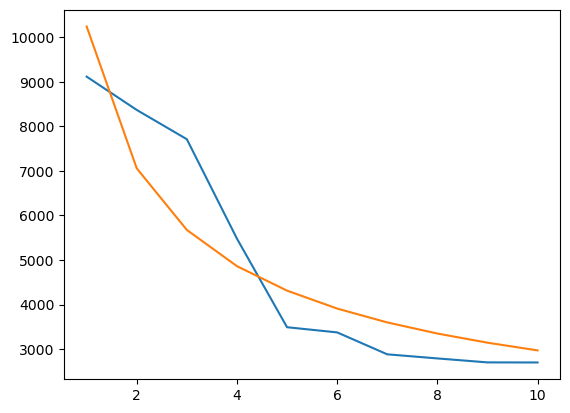

In [678]:
import numpy as np
from scipy.optimize import curve_fit

def powerlaw(x, A, s):
    return A * np.power(x, s)

# data
Y = np.array([9115, 8368, 7711, 5480, 3492, 3376, 2884, 2792, 2703, 2701])
X = np.arange(Y.shape[0]) + 1.0

# initial guess for variables
p0 = [100, -1]
# fit data
params, cov = curve_fit(f=powerlaw, xdata=X, ydata=Y, p0=p0, bounds=(-np.inf, np.inf))

print("A =", params[0], "+/-", cov[0,0]**0.5)
print("s =", params[1], "+/-", cov[1,1]**0.5)

# optionally plot
import matplotlib.pyplot as plt
plt.plot(X,Y)
plt.plot(X, powerlaw(X, params[0], params[1]))
plt.show()

## <mark>Exercises</mark>

### Working effectively with dataframes

Recall the `curve_fit()` method from SciPy discussed above, and imagine that we want to fit powerlaws to every row in a large dataframe. How can this be done effectively?

First define the `powerlaw()` function and another function for fitting a row of numbers:
```python
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def powerlaw(x, A, s):
    return A * np.power(x, s)

def fit_powerlaw(row):
    X = np.arange(row.shape[0]) + 1.0
    params, cov = curve_fit(f=powerlaw, xdata=X, ydata=row, p0=[100, -1], bounds=(-np.inf, np.inf))
    return params[1]
```

Next load a dataset with multiple rows similar to the one used in the example above:
```python
df = pd.read_csv("https://raw.githubusercontent.com/ENCCS/hpda-python/main/content/data/results.csv")
# print first few rows
df.head()
```

Now consider these four different ways of fitting a powerlaw to each row of the dataframe:
```python
# 1. Loop

powers = []
for row_indx in range(df.shape[0]):
    row = df.iloc[row_indx,1:]
    p = fit_powerlaw(row)
    powers.append(p)
```

```python
# 2. `iterrows()

powers = []
for row_indx,row in df.iterrows():
    p = fit_powerlaw(row[1:])
    powers.append(p)
```

```python
# 3. `apply()

powers = df.iloc[:,1:].apply(fit_powerlaw, axis=1)
```

```python
# 4. `apply()` with `raw=True`

# raw=True passes numpy ndarrays instead of series to fit_powerlaw
powers = df.iloc[:,1:].apply(fit_powerlaw, axis=1, raw=True)
```

Which one do you think is most efficient? You can measure the execution time by adding `%%timeit` to the first line of a Jupyter code cell. More on timing and profiling in a later episode.

<details>

<summary>Solution</summary>

The execution time for four different methods are described below. Note that you may get different numbers when you run these examples.

```python
# 1 Loop

%%timeit
powers = []
for row_indx in range(df.shape[0]):
   row = df.iloc[row_indx,1:]
   p = fit_powerlaw(row)
   powers.append(p)

# 33.6 ms ± 682 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
```

```python
# 2. `iterrows()`

%%timeit
powers = []
for row_indx,row in df.iterrows():
   p = fit_powerlaw(row[1:])
   powers.append(p)

# 28.7 ms ± 947 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
```

```python
# 3. `apply()`

%%timeit
powers = df.iloc[:,1:].apply(fit_powerlaw, axis=1)

# 26.1 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
```

```python
# 4. `apply()` with `raw=True`

%%timeit
powers = df.iloc[:,1:].apply(fit_powerlaw, axis=1, raw=True)

# 24 ms ± 1.27 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
```
</details>

### Further analysis of the Titanic passenger list dataset

Consider the titanic dataset.
> If you haven’t done so already, load it into a dataframe before the exercises:
> `import pandas as pd; url = "https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv"; titanic = pd.read_csv(url, index_col="Name")`
- Compute the mean age of the first 10 passengers by slicing and the `mean` method
- Using boolean indexing, compute the survival rate (mean of “Survived” values) among passengers over and under the average age.
Now investigate the family size of the passengers (*i.e.* the “SibSp” column):
- What different family sizes exist in the passenger list?
    - Hint: try the `unique()` method
- What are the names of the people in the largest family group?
- (Advanced) Create histograms showing the distribution of family sizes for passengers split by the fare, i.e. one group of high-fare passengers (where the fare is above average) and one for low-fare passengers
    - Hint: instead of an existing column name, you can give a lambda function as a parameter to `hist` to compute a value on the fly. For example `lambda x: "Poor" if titanic["Fare"].loc[x] < titanic["Fare"].mean() else "Rich"`).

<details>

<summary>Solution</summary>

1. Mean age of the first 10 passengers: 
	- `titanic.iloc[:10,:]["Age"].mean()` or 
	- `titanic.iloc[:10,4].mean()` or 
	- `titanic.loc[:"Nasser, Mrs. Nicholas (Adele Achem)", "Age"].mean()`

2. Survival rate among passengers over and under average age:
	- `titanic[titanic["Age"] > titanic["Age"].mean()]["Survived"].mean()` and 
	- `titanic[titanic["Age"] < titanic["Age"].mean()]["Survived"].mean()`

3. Existing family sizes: `titanic["SibSp"].unique()`

4. Names of members of largest family(ies): `titanic[titanic["SibSp"] == 8].index`

5. `titanic.hist("SibSp", lambda x: "Poor" if titanic["Fare"].loc[x] < titanic["Fare"].mean() else "Rich", rwidth=0.9)`
</details>

## 2.6 Keypoints

- NumPy provides a static array data structure, fast mathematical operations for arrays and tools for linear algebra and random numbers
- Pandas dataframes are a good data structure for tabular data
- Dataframes allow both simple and advanced analysis in very compact form
- SciPy contains a lot of interfaces to battle-tested numerical routines

--- 

Don't forget to check out additional [**course materials**]() from XXX. Please [**contact us**]() if you want to reuse these course materials in your teaching. You can also join the [**XXX channel**]() to share your experience and get more help from the community.

---

## Licensing

Copyright © 2025 XXX. This material is released by XXX under the Creative Commons Attribution 4.0 International (CC BY 4.0). These materials may include references to hardware and software developed by other entities; all applicable licensing and copyrights apply.